In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


# Task 1 – Natural Gas Price Analysis and Extrapolation

We begin by loading the historical natural gas price data.  
The dataset contains monthly observations of natural gas prices, where each data point represents the market price of natural gas delivered at the end of a calendar month.

Before performing any analysis, we convert the date column into a proper datetime format and ensure the dataset is ordered chronologically.

In [31]:
df = pd.read_csv("/Users/allisonxu/Library/CloudStorage/OneDrive-Personal/DS_Projects/JPM/Nat_Gas.csv")
df['Dates'] = pd.to_datetime(df['Dates'])
df = df.sort_values('Dates')
df.head()

/var/folders/0l/nv2w_zqn0rncbhxnnml3xmdw0000gn/T/ipykernel_12038/3022297419.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


**Visualizing Historical Prices**

To better understand the structure of the data, we plot the historical natural gas prices over time.

Seasonality is particularly important in natural gas markets because demand often increases during winter due to heating needs.

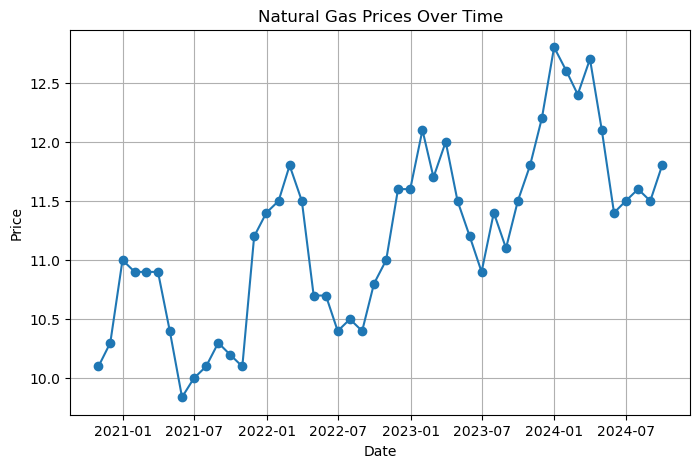

In [32]:
plt.figure(figsize=(8,5))
plt.plot(df['Dates'], df['Prices'], marker='o')

plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True)
plt.show()

Because regression models require numerical inputs, we convert the timeline into a numerical index representing the number of months since the beginning of the dataset.

In [33]:
df['time_index'] = range(len(df))
df.head()

,Dates,Prices,time_index
0,2020-10-31,10.1,0
1,2020-11-30,10.3,1
2,2020-12-31,11.0,2
3,2021-01-31,10.9,3
4,2021-02-28,10.9,4


**Modeling Seasonality**

Natural gas prices exhibit strong seasonal behavior due to changes in demand throughout the year.

To capture this seasonal pattern, we introduce sinusoidal variables:

$$
sin(2πt/12)
$$
$$
cos(2πt/12)
$$

These terms model a repeating yearly cycle because the period is 12 months.

In [34]:
df['sin'] = np.sin(2*np.pi*df['time_index']/12)
df['cos'] = np.cos(2*np.pi*df['time_index']/12)

df.head()

,Dates,Prices,time_index,sin,cos
0,2020-10-31,10.1,0,0.000000,1.000000e+00
1,2020-11-30,10.3,1,0.500000,8.660254e-01
2,2020-12-31,11.0,2,0.866025,5.000000e-01
3,2021-01-31,10.9,3,1.000000,6.123234e-17
4,2021-02-28,10.9,4,0.866025,-5.000000e-01


**Building the Seasonal Regression Model**

We model the natural gas price as a combination of:

- a linear trend component
- a seasonal component

The model is defined as:
$$
Price = a*t + b + c*sin(2πt/12) + d*cos(2πt/12)
$$
We estimate the parameters of this model using linear regression.

In [35]:
from sklearn.linear_model import LinearRegression

X = df[['time_index','sin','cos']]
y = df['Prices']

model = LinearRegression()

model.fit(X, y)

LinearRegression()

**Comparing Model Predictions with Historical Data**

To evaluate how well the model fits the data, we compare the predicted prices with the observed prices.

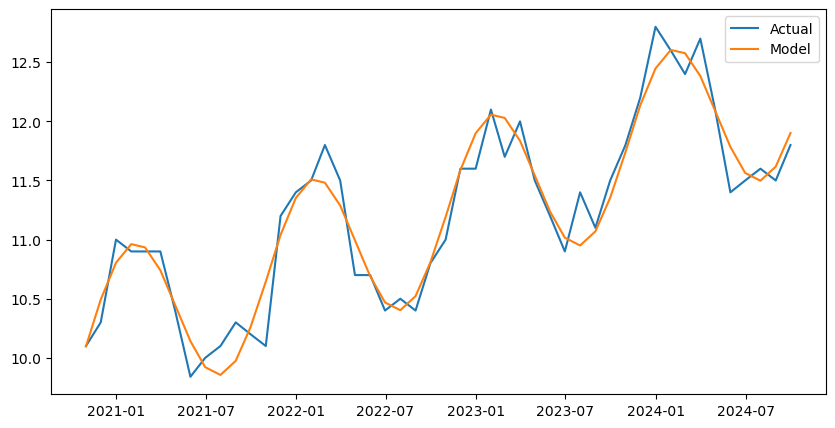

In [36]:
df['predicted'] = model.predict(X)

plt.figure(figsize=(10,5))

plt.plot(df['Dates'], df['Prices'], label="Actual")
plt.plot(df['Dates'], df['predicted'], label="Model")

plt.legend()
plt.show()

**Price Estimation Function**

To make the model usable for pricing storage contracts, we implement a function that estimates the natural gas price for any input date.

The function converts the input date into a time index and computes the corresponding seasonal variables before applying the regression model.

In [37]:
def estimate_price(date):

    date = pd.to_datetime(date)

    start = df['Dates'].min()

    t = (date.year-start.year)*12 + (date.month-start.month)

    sin = np.sin(2*np.pi*t/12)
    cos = np.cos(2*np.pi*t/12)

    price = model.predict([[t,sin,cos]])

    return float(price[0])

In [38]:
estimate_price("2025-06-15")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


12.111192877636421

# Task 2 – Pricing a Natural Gas Storage Contract

After building a price estimation model in Task 1, the trading desk can now estimate natural gas prices at any given date.

The next step is to build a prototype pricing model for a natural gas storage contract.

The value of a storage contract is determined by the difference between:

- the price at which natural gas is purchased 
- the price at which natural gas is sold 

However, several costs must also be considered, including storage costs and operational costs such as injection and withdrawal fees.

The goal of this task is to implement a function that calculates the value of the contract based on these inputs.

**Contract Valuation Logic**

The value of the contract can be understood as the total profit generated from storing and later selling natural gas.

$$
Profit = (Sell Price − Buy Price) × Volume - Cost
$$
The possible cost includes the following: 

- Storage costs (charged per unit time)
- Injection costs
- Withdrawal costs

**Contract Pricing Function**

The function will:

1. Estimate purchase prices using the price model from Task 1
2. Estimate selling prices
3. Compute profit from buying low and selling high
4. Subtract storage and operational costs

In [39]:
def price_storage_contract(injection_dates,
                           withdrawal_dates,
                           volume,
                           max_volume,
                           injection_rate,
                           withdrawal_rate,
                           storage_cost_per_month,
                           injection_cost,
                           withdrawal_cost):

    total_profit = 0
    total_storage_cost = 0
    total_operational_cost = 0
    
    current_storage = 0

    for in_d, w_d in zip(injection_dates, withdrawal_dates):

        buy_price = estimate_price(in_d)
        sell_price = estimate_price(w_d)

        traded_volume = min(volume, injection_rate, withdrawal_rate)

        if current_storage + traded_volume > max_volume:
            traded_volume = max_volume - current_storage

        purchase_cost = buy_price * traded_volume
        sale_revenue = sell_price * traded_volume

        profit = sale_revenue - purchase_cost

        inj_date = pd.to_datetime(in_d)
        wdr_date = pd.to_datetime(w_d)

        months_stored = (wdr_date.year - inj_date.year)*12 + (wdr_date.month - inj_date.month)

        storage_cost = months_stored * storage_cost_per_month

        operational_cost = injection_cost + withdrawal_cost

        total_profit += profit
        total_storage_cost += storage_cost
        total_operational_cost += operational_cost

        current_storage += traded_volume

    contract_value = total_profit - total_storage_cost - total_operational_cost

    return contract_value

**Example Contract**

We now test the pricing model using sample inputs.

Assume a trader buys natural gas during summer and sells it during winter.

In [40]:
injection_dates = ["2025-06-01","2025-07-01"]
withdrawal_dates = ["2025-12-01","2026-01-01"]

contract_value = price_storage_contract(
    injection_dates=injection_dates,
    withdrawal_dates=withdrawal_dates,
    volume=1_000_000,
    max_volume=2_000_000,
    injection_rate=1_000_000,
    withdrawal_rate=1_000_000,
    storage_cost_per_month=100000,
    injection_cost=10000,
    withdrawal_cost=10000
)

contract_value

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


1844984.841540033

**Interpretation**

The output of the pricing function represents the estimated value of the storage contract.

This prototype model can help traders evaluate different storage strategies before committing to a contract.

# Task 3 - Loan Default Prediction (Probability of Default)

**Business Problem**

Retail banking is experiencing higher-than-expected default rates on personal loans.

A default happens when a borrower stops making required payments.

To manage this risk, the bank wants to estimate:

- **PD (Probability of Default)**: probability that a borrower will default
- **Expected Loss (EL)**: expected financial loss if a borrower defaults

The expected loss formula used in credit risk is:
$$
Expected Loss = PD × Loan Amount × (1 − Recovery Rate)
$$
Where:

- PD = probability of default predicted by the model
- Recovery Rate = proportion of loan recovered after default
- In this task, Recovery Rate = 10%

So:
$$
Expected Loss = PD × Loan Amount × 0.9
$$
We will build a predictive model using borrower characteristics such as:

- income
- fico score
- total debt
- loan outstanding
- years employed

**Load the dataset**

In [41]:
loan = pd.read_csv('/Users/allisonxu/Library/CloudStorage/OneDrive-Personal/DS_Projects/JPM/Loan_Data.csv')
loan.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


**Dataset Description**

Each row represents a borrower.

Variables:
- credit_lines_outstanding: number of credit accounts the customer has.

- loan_amt_outstanding: Current loan amount.

- total_debt_outstanding: total debt the borrower currently owes.

- income: borrower annual income.

- years_employed: number of years employed.

- fico_score: credit score measuring creditworthiness.

- default: 1 = borrower defaulted, 0 = borrower did not default

**Define Features and Target**

X = input variables

y = target_predict_value (default)

In [42]:
X = loan[['credit_lines_outstanding',
        'loan_amt_outstanding',
        'total_debt_outstanding',
        'income',
        'years_employed',
        'fico_score']]

y = loan['default']

**Split Data into Training and Testing Sets**

Training set: 80% <br>
Testing set: 20%

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Logistic Regression Model**

We use Logistic Regression because the output we want is a probability (0 to 1), and Logistic regression maps predictions into the range (0,1).

The logistic function is:
$$
P(default) = 1 / (1 + e^{-z})
$$
where
$$
z = β0 + β1X1 + β2X2 + ...
$$

**Train the Model**

In [44]:
model = LogisticRegression()

model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

**Predict Probability of Default**

In [46]:
pd_predictions = model.predict_proba(X_test)[:,1]

In [47]:
recovery_rate = 0.10

loan_amounts = X_test['loan_amt_outstanding']

expected_loss = pd_predictions * loan_amounts * (1 - recovery_rate)

**Build Final Expected Loss Function**

We now create a function that:

1. Takes borrower characteristics as input
2. Predicts probability of default (PD)
3. Calculates expected loss

In [48]:
def predict_expected_loss(model,
                          credit_lines_outstanding,
                          loan_amt_outstanding,
                          total_debt_outstanding,
                          income,
                          years_employed,
                          fico_score):

    data = pd.DataFrame({
        'credit_lines_outstanding':[credit_lines_outstanding],
        'loan_amt_outstanding':[loan_amt_outstanding],
        'total_debt_outstanding':[total_debt_outstanding],
        'income':[income],
        'years_employed':[years_employed],
        'fico_score':[fico_score]
    })

    pd_value = model.predict_proba(data)[0][1]

    expected_loss = pd_value * loan_amt_outstanding * (1 - recovery_rate)

    return expected_loss

In [49]:
predict_expected_loss(
    model,
    credit_lines_outstanding=2,
    loan_amt_outstanding=10000,
    total_debt_outstanding=20000,
    income=60000,
    years_employed=5,
    fico_score=650
)

np.float64(8999.979918274546)

# Task 4 — FICO Score Quantization

**Objective**

The goal of this task is to convert FICO scores into categorical ratings. We will map FICO scores into rating buckets.

**Explore FICO Score Distribution**

Before creating buckets, we first examine how FICO scores are distributed in the dataset.

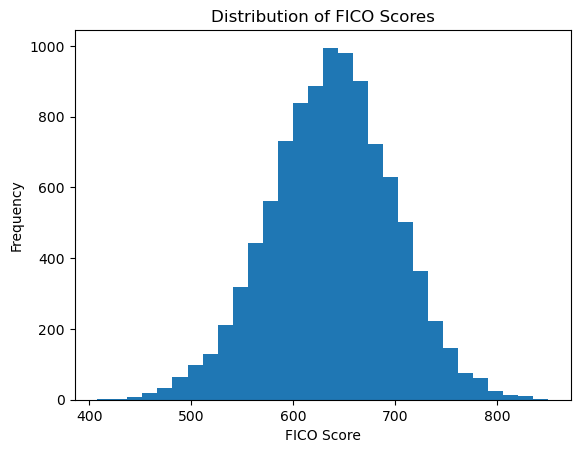

In [51]:
plt.hist(loan['fico_score'], bins=30)

plt.xlabel("FICO Score")
plt.ylabel("Frequency")
plt.title("Distribution of FICO Scores")

plt.show()

### Method 1 — Mean Squared Error Bucketing

In this method, each bucket represents all values inside it with a single representative value.

The goal is to minimize the mean squared error between the true FICO scores and their bucket representative.
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2
$$

In [52]:
def mse_buckets(data, num_buckets):

    min_score = data.min()
    max_score = data.max()

    edges = np.linspace(min_score, max_score, num_buckets+1)

    return edges

In [53]:
bucket_edges = mse_buckets(loan['fico_score'], 5)

bucket_edges

array([408. , 496.4, 584.8, 673.2, 761.6, 850. ])

**Convert FICO Scores to Ratings**

Using the bucket boundaries, we assign a rating to each borrower.

Lower rating = better credit quality.

In [58]:
loan['rating'] = pd.cut(
    loan['fico_score'],
    bins=bucket_edges,
    labels=[5,4,3,2,1]
)

loan[['fico_score','rating']].head()

,fico_score,rating
0,605,3
1,572,4
2,602,3
3,612,3
4,631,3


### Method 2 — Log Likelihood Optimization

A more sophisticated method is to maximize the log likelihood function.

Each bucket has:

$n_i$ = number of observations  
$k_i$ = number of defaults  

The probability of default in bucket $i$ is

$p_i = k_i / n_i$

The objective is to maximize:
$$
LL = \sum_{i=1}^{r}[k_i\ln p_i + (n_i-k_i)\ln (1-p_i)]
$$
This ensures that buckets capture meaningful differences in default risk.

In [59]:
def log_likelihood_bucket(data, defaults, bins):

    data_sorted = data.sort_values()
    edges = np.percentile(data_sorted, np.linspace(0,100,bins+1))

    return edges

In [61]:
edges_ll = log_likelihood_bucket(
    loan['fico_score'],
    loan['default'],
    5
)

edges_ll

array([408., 587., 623., 653., 688., 850.])

**Create Rating Map**

In [65]:
rating_map = pd.cut(
    loan['fico_score'],
    bins=edges_ll,
    labels=[5,4,3,2,1]
)

loan['rating_ll'] = rating_map

loan[['fico_score','rating_ll']].head()

,fico_score,rating_ll
0,605,4
1,572,5
2,602,4
3,612,4
4,631,3
